In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [2]:
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.
x_train=np.expand_dims(x_train,-1); x_test=np.expand_dims(x_test,-1)
noise=0.5
x_train_noisy=np.clip(x_train+noise*np.random.normal(size=x_train.shape),0,1)
x_test_noisy=np.clip(x_test+noise*np.random.normal(size=x_test.shape),0,1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


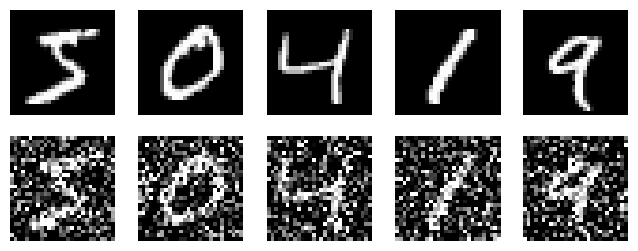

In [3]:
plt.figure(figsize=(8,3))
for i in range(5):
 plt.subplot(2,5,i+1); plt.imshow(x_train[i].squeeze(),cmap='gray'); plt.axis('off')
 plt.subplot(2,5,i+6); plt.imshow(x_train_noisy[i].squeeze(),cmap='gray'); plt.axis('off')
plt.show()

In [4]:
inp=Input((28,28,1))
x=Conv2D(32,3,activation='relu',padding='same')(inp)
x=MaxPooling2D(2,padding='same')(x)
x=Conv2D(32,3,activation='relu',padding='same')(x)
x=UpSampling2D(2)(x)
out=Conv2D(1,3,activation='sigmoid',padding='same')(x)
model=Model(inp,out)
model.compile('adam','binary_crossentropy')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,857 (38.50 KB)

 Trainable params: 9,857 (38.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
hist=model.fit(x_train_noisy,x_train,epochs=5,batch_size=128,validation_data=(x_test_noisy,x_test))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 203ms/step - loss: 0.1697 - val_loss: 0.1125
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 90s 192ms/step - loss: 0.1115 - val_loss: 0.1090
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 90s 191ms/step - loss: 0.1092 - val_loss: 0.1074
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 90s 192ms/step - loss: 0.1073 - val_loss: 0.1057
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 195ms/step - loss: 0.1060 - val_loss: 0.1045


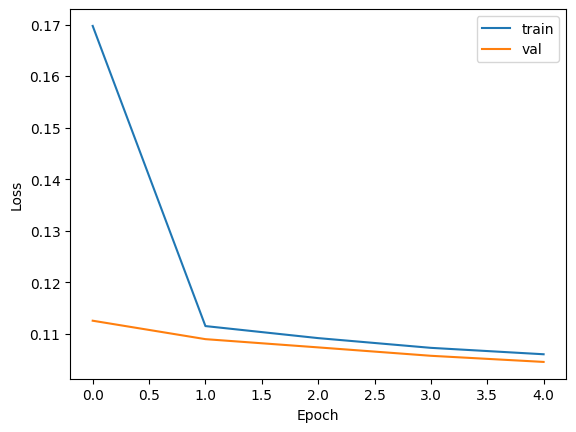

In [6]:
plt.plot(hist.history['loss'],label='train')
plt.plot(hist.history['val_loss'],label='val')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


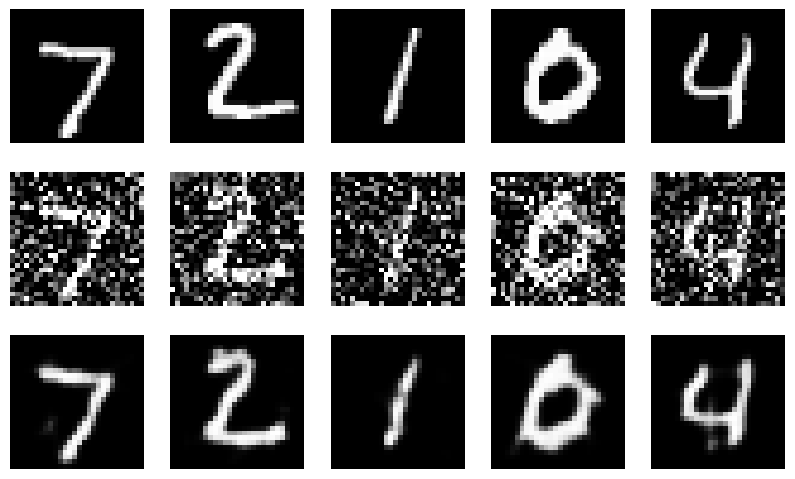

In [7]:
decoded=model.predict(x_test_noisy[:5])
plt.figure(figsize=(10,6))
for i in range(5):
 plt.subplot(3,5,i+1); plt.imshow(x_test[i].squeeze(),cmap='gray'); plt.axis('off')
 plt.subplot(3,5,i+6); plt.imshow(x_test_noisy[i].squeeze(),cmap='gray'); plt.axis('off')
 plt.subplot(3,5,i+11); plt.imshow(decoded[i].squeeze(),cmap='gray'); plt.axis('off')
plt.show()